DATA SCIENCE WORKFLOW

Objective: Predict Titanic Survival

Dataset Shape
(891, 15)

First Five Rows
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


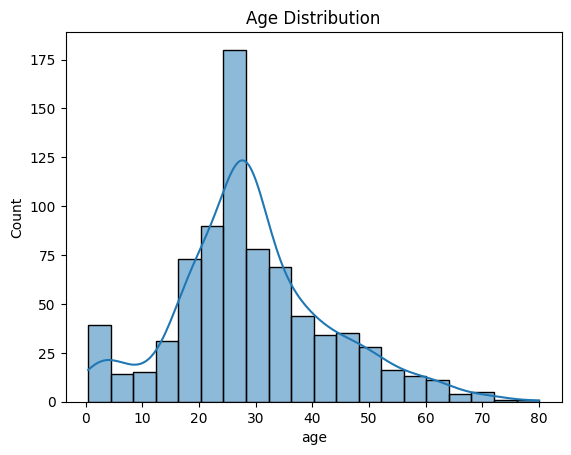

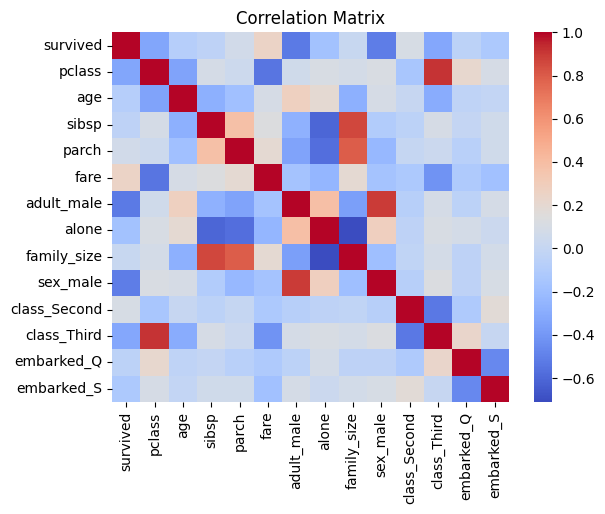


Accuracy
0.6942675159235668

Precision
0.7083333333333334

Recall
0.5

Confusion Matrix
[[75 14]
 [34 34]]

Workflow Completed Successfully


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

print("="*60)
print("DATA SCIENCE WORKFLOW")
print("="*60)

# ----------------------------------
# 1. Problem Definition
# ----------------------------------

objective = "Predict Titanic Survival"

print("\nObjective:", objective)

# ----------------------------------
# 2. Data Collection
# ----------------------------------

df = sns.load_dataset("titanic")

print("\nDataset Shape")
print(df.shape)

print("\nFirst Five Rows")
print(df.head())

# ----------------------------------
# 3. Data Cleaning
# ----------------------------------

df['age'] = df['age'].fillna(
    df['age'].median()
)

df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

df.drop_duplicates(inplace=True)

# ----------------------------------
# Feature Engineering
# ----------------------------------

df['family_size'] = (
    df['sibsp'] + df['parch']
)

# ----------------------------------
# Encoding
# ----------------------------------

df = pd.get_dummies(
    df,
    columns=['sex','class','embarked'],
    drop_first=True
)

# ----------------------------------
# 4. EDA
# ----------------------------------

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# ----------------------------------
# 5. Data Modeling
# ----------------------------------

X = df.drop(columns=['survived'])

# Keep numeric columns only
X = X.select_dtypes(include=['number'])

y = df['survived']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train,y_train)

# ----------------------------------
# 6. Model Evaluation
# ----------------------------------

y_pred = model.predict(X_test)

print("\nAccuracy")
print(accuracy_score(y_test,y_pred))

print("\nPrecision")
print(precision_score(y_test,y_pred))

print("\nRecall")
print(recall_score(y_test,y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\nWorkflow Completed Successfully")